<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Space X  Falcon 9 First Stage Landing Prediction**


 ## Lab 2: Data wrangling 


Estimated time needed: **60** minutes


In this lab, we will perform some Exploratory Data Analysis (EDA) to find some patterns in the data and determine what would be the label for training supervised models. 

In the data set, there are several different cases where the booster did not land successfully. Sometimes a landing was attempted but failed due to an accident; for example, <code>True Ocean</code> means the mission outcome was successfully  landed to a specific region of the ocean while <code>False Ocean</code> means the mission outcome was unsuccessfully landed to a specific region of the ocean. <code>True RTLS</code> means the mission outcome was successfully  landed to a ground pad <code>False RTLS</code> means the mission outcome was unsuccessfully landed to a ground pad.<code>True ASDS</code> means the mission outcome was successfully landed on  a drone ship <code>False ASDS</code> means the mission outcome was unsuccessfully landed on a drone ship. 

In this lab we will mainly convert those outcomes into Training Labels with `1` means the booster successfully landed `0` means it was unsuccessful.


Falcon 9 first stage will land successfully


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/landing_1.gif)


Several examples of an unsuccessful landing are shown here:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/crash.gif)


## Objectives
Perform exploratory  Data Analysis and determine Training Labels 

- Exploratory Data Analysis
- Determine Training Labels 


----


## Import Libraries and Define Auxiliary Functions


We will import the following libraries.


In [99]:
# Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np

### Data Analysis 


Load Space X dataset, from last section.


In [100]:
df=pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_1.csv")
df.head(10)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857


Identify and calculate the percentage of the missing values in each attribute


In [101]:
df.isnull().sum()/len(df)*100

FlightNumber       0.000000
Date               0.000000
BoosterVersion     0.000000
PayloadMass        0.000000
Orbit              0.000000
LaunchSite         0.000000
Outcome            0.000000
Flights            0.000000
GridFins           0.000000
Reused             0.000000
Legs               0.000000
LandingPad        28.888889
Block              0.000000
ReusedCount        0.000000
Serial             0.000000
Longitude          0.000000
Latitude           0.000000
dtype: float64

Identify which columns are numerical and categorical:


In [102]:
df.dtypes

FlightNumber        int64
Date               object
BoosterVersion     object
PayloadMass       float64
Orbit              object
LaunchSite         object
Outcome            object
Flights             int64
GridFins             bool
Reused               bool
Legs                 bool
LandingPad         object
Block             float64
ReusedCount         int64
Serial             object
Longitude         float64
Latitude          float64
dtype: object

### TASK 1: Calculate the number of launches on each site

The data contains several Space X  launch facilities: <a href='https://en.wikipedia.org/wiki/List_of_Cape_Canaveral_and_Merritt_Island_launch_sites'>Cape Canaveral Space</a> Launch Complex 40  <b>VAFB SLC 4E </b> , Vandenberg Air Force Base Space Launch Complex 4E <b>(SLC-4E)</b>, Kennedy Space Center Launch Complex 39A <b>KSC LC 39A </b>.The location of each Launch Is placed in the column <code>LaunchSite</code>


Next, let's see the number of launches for each site.

Use the method  <code>value_counts()</code> on the column <code>LaunchSite</code> to determine the number of launches  on each site: 


In [103]:
# Apply value_counts() on column LaunchSite
launch_site_counts = df['LaunchSite'].value_counts()
print(launch_site_counts)



LaunchSite
CCAFS SLC 40    55
KSC LC 39A      22
VAFB SLC 4E     13
Name: count, dtype: int64


Each launch aims to an dedicated orbit, and here are some common orbit types:




* <b>LEO</b>: Low Earth orbit (LEO)is an Earth-centred orbit with an altitude of 2,000 km (1,200 mi) or less (approximately one-third of the radius of Earth),[1] or with at least 11.25 periods per day (an orbital period of 128 minutes or less) and an eccentricity less than 0.25.[2] Most of the manmade objects in outer space are in LEO <a href='https://en.wikipedia.org/wiki/Low_Earth_orbit'>[1]</a>.

* <b>VLEO</b>: Very Low Earth Orbits (VLEO) can be defined as the orbits with a mean altitude below 450 km. Operating in these orbits can provide a number of benefits to Earth observation spacecraft as the spacecraft operates closer to the observation<a href='https://www.researchgate.net/publication/271499606_Very_Low_Earth_Orbit_mission_concepts_for_Earth_Observation_Benefits_and_challenges'>[2]</a>.


* <b>GTO</b> A geosynchronous orbit is a high Earth orbit that allows satellites to match Earth's rotation. Located at 22,236 miles (35,786 kilometers) above Earth's equator, this position is a valuable spot for monitoring weather, communications and surveillance. Because the satellite orbits at the same speed that the Earth is turning, the satellite seems to stay in place over a single longitude, though it may drift north to south,” NASA wrote on its Earth Observatory website <a  href="https://www.space.com/29222-geosynchronous-orbit.html" >[3] </a>.


* <b>SSO (or SO)</b>: It is a Sun-synchronous orbit  also called a heliosynchronous orbit is a nearly polar orbit around a planet, in which the satellite passes over any given point of the planet's surface at the same local mean solar time <a href="https://en.wikipedia.org/wiki/Sun-synchronous_orbit">[4] <a>.
    
    
    
* <b>ES-L1 </b>:At the Lagrange points the gravitational forces of the two large bodies cancel out in such a way that a small object placed in orbit there is in equilibrium relative to the center of mass of the large bodies. L1 is one such point between the sun and the earth <a href="https://en.wikipedia.org/wiki/Lagrange_point#L1_point">[5]</a> .
    
    
* <b>HEO</b> A highly elliptical orbit, is an elliptic orbit with high eccentricity, usually referring to one around Earth <a href="https://en.wikipedia.org/wiki/Highly_elliptical_orbit">[6]</a>.


* <b> ISS </b> A modular space station (habitable artificial satellite) in low Earth orbit. It is a multinational collaborative project between five participating space agencies: NASA (United States), Roscosmos (Russia), JAXA (Japan), ESA (Europe), and CSA (Canada)<a href="https://en.wikipedia.org/wiki/International_Space_Station"> [7] </a>


* <b> MEO </b> Geocentric orbits ranging in altitude from 2,000 km (1,200 mi) to just below geosynchronous orbit at 35,786 kilometers (22,236 mi). Also known as an intermediate circular orbit. These are "most commonly at 20,200 kilometers (12,600 mi), or 20,650 kilometers (12,830 mi), with an orbital period of 12 hours <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [8] </a>


* <b> HEO </b> Geocentric orbits above the altitude of geosynchronous orbit (35,786 km or 22,236 mi) <a href="https://en.wikipedia.org/wiki/List_of_orbits"> [9] </a>


* <b> GEO </b> It is a circular geosynchronous orbit 35,786 kilometres (22,236 miles) above Earth's equator and following the direction of Earth's rotation <a href="https://en.wikipedia.org/wiki/Geostationary_orbit"> [10] </a>


* <b> PO </b> It is one type of satellites in which a satellite passes above or nearly above both poles of the body being orbited (usually a planet such as the Earth <a href="https://en.wikipedia.org/wiki/Polar_orbit"> [11] </a>

some are shown in the following plot:


![](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DS0701EN-SkillsNetwork/api/Images/Orbits.png)


### TASK 2: Calculate the number and occurrence of each orbit


 Use the method  <code>.value_counts()</code> to determine the number and occurrence of each orbit in the  column <code>Orbit</code>


In [104]:
# Apply value_counts on Orbit 
occurence_each_orbit = df['Orbit'].value_counts()
print(occurence_each_orbit)


Orbit
GTO      27
ISS      21
VLEO     14
PO        9
LEO       7
SSO       5
MEO       3
ES-L1     1
HEO       1
SO        1
GEO       1
Name: count, dtype: int64


### TASK 3: Calculate the number and occurence of mission outcome of the orbits


Use the method <code>.value_counts()</code> on the column <code>Outcome</code> to determine the number of <code>landing_outcomes</code>.Then assign it to a variable landing_outcomes.


In [105]:
# landing_outcomes = values on Outcome column
landing_outcomes= df['Outcome'].value_counts()
print(landing_outcomes)

Outcome
True ASDS      41
None None      19
True RTLS      14
False ASDS      6
True Ocean      5
False Ocean     2
None ASDS       2
False RTLS      1
Name: count, dtype: int64


<code>True Ocean</code> means the mission outcome was successfully  landed to a specific region of the ocean while <code>False Ocean</code> means the mission outcome was unsuccessfully landed to a specific region of the ocean. <code>True RTLS</code> means the mission outcome was successfully  landed to a ground pad <code>False RTLS</code> means the mission outcome was unsuccessfully landed to a ground pad.<code>True ASDS</code> means the mission outcome was successfully  landed to a drone ship <code>False ASDS</code> means the mission outcome was unsuccessfully landed to a drone ship. <code>None ASDS</code> and <code>None None</code> these represent a failure to land.


In [106]:
for i,outcome in enumerate(landing_outcomes.keys()):
    print(i,outcome)

0 True ASDS
1 None None
2 True RTLS
3 False ASDS
4 True Ocean
5 False Ocean
6 None ASDS
7 False RTLS


We create a set of outcomes where the second stage did not land successfully:


In [107]:
bad_outcomes=set(landing_outcomes.keys()[[1,3,5,6,7]])
bad_outcomes

{'False ASDS', 'False Ocean', 'False RTLS', 'None ASDS', 'None None'}

### TASK 4: Create a landing outcome label from Outcome column


Using the <code>Outcome</code>,  create a list where the element is zero if the corresponding  row  in  <code>Outcome</code> is in the set <code>bad_outcome</code>; otherwise, it's one. Then assign it to the variable <code>landing_class</code>:


In [108]:
# landing_class = 0 if bad_outcome
# landing_class = 1 otherwise 
df['landing_class'] = df['Outcome'].apply(lambda x: 0 if x == 'Failure' else 1)

This variable will represent the classification variable that represents the outcome of each launch. If the value is zero, the  first stage did not land successfully; one means  the first stage landed Successfully 


In [109]:
#df['Class']=landing_class
df[['landing_class']].head(8)

,landing_class
0,1
1,1
2,1
3,1
4,1
5,1
6,1
7,1


In [110]:
df.head(10)



,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,landing_class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,1
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,1
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,1
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,1
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,1
5,6,2014-01-06,Falcon 9,3325.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1005,-80.577366,28.561857,1
6,7,2014-04-18,Falcon 9,2296.000000,ISS,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1006,-80.577366,28.561857,1
7,8,2014-07-14,Falcon 9,1316.000000,LEO,CCAFS SLC 40,True Ocean,1,False,False,True,NaN,1.0,0,B1007,-80.577366,28.561857,1
8,9,2014-08-05,Falcon 9,4535.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1008,-80.577366,28.561857,1
9,10,2014-09-07,Falcon 9,4428.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1011,-80.577366,28.561857,1


We can use the following line of code to determine  the success rate:


In [111]:
df["landing_class"].mean()

1.0

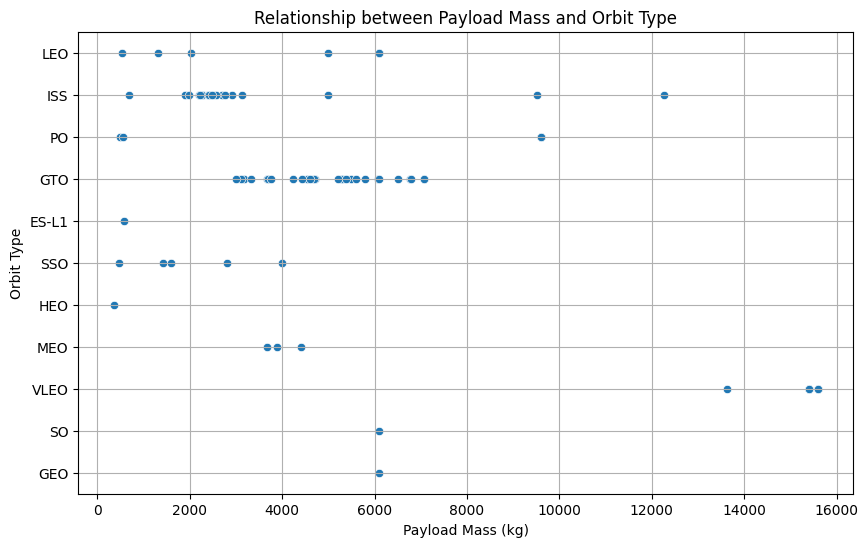

In [112]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='PayloadMass', y='Orbit')

# Customize the plot
plt.title('Relationship between Payload Mass and Orbit Type')
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Orbit Type')

# Add grid for better readability
plt.grid(True)

# Show the plot
plt.show()


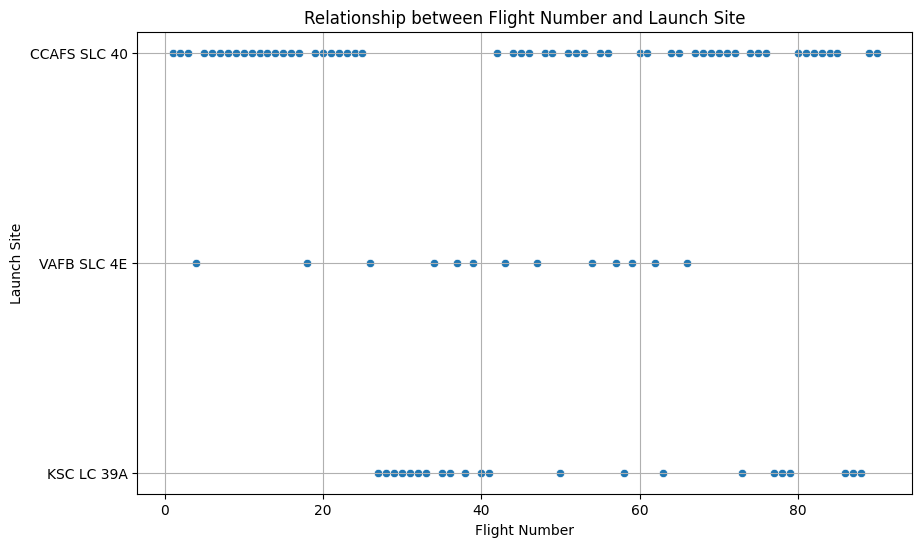

In [113]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FlightNumber', y='LaunchSite')

# Customize plot
plt.title('Relationship between Flight Number and Launch Site')
plt.xlabel('Flight Number')
plt.ylabel('Launch Site')
plt.grid(True)

plt.show()


We can now export it to a CSV for the next section,but to make the answers consistent, in the next lab we will provide data in a pre-selected date range.


In [114]:

# Filter records where launch site begins with 'CCA'
cca_launches = df[df['LaunchSite'].str.startswith('CCA')].head(5)

# Display results
print("\nFirst 5 launches from sites beginning with 'CCA':")
print(cca_launches[['FlightNumber', 'Date', 'LaunchSite', 'PayloadMass', 'Orbit']])




First 5 launches from sites beginning with 'CCA':
   FlightNumber        Date    LaunchSite  PayloadMass Orbit
0             1  2010-06-04  CCAFS SLC 40  6104.959412   LEO
1             2  2012-05-22  CCAFS SLC 40   525.000000   LEO
2             3  2013-03-01  CCAFS SLC 40   677.000000   ISS
4             5  2013-12-03  CCAFS SLC 40  3170.000000   GTO
5             6  2014-01-06  CCAFS SLC 40  3325.000000   GTO


<code>df.to_csv("dataset_part_2.csv", index=False)</code>


In [115]:
# Filter for F9 v1.1 boosters and calculate average payload mass
f9_v1_1_data = df[df['BoosterVersion'] == 'F9 v1.1']
average_payload = f9_v1_1_data['PayloadMass'].mean()

print("F9 v1.1 Booster Statistics:")
print(f"Number of launches: {len(f9_v1_1_data)}")
print(f"Average payload mass: {average_payload:.2f} kg")


F9 v1.1 Booster Statistics:
Number of launches: 0
Average payload mass: nan kg


In [116]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [117]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


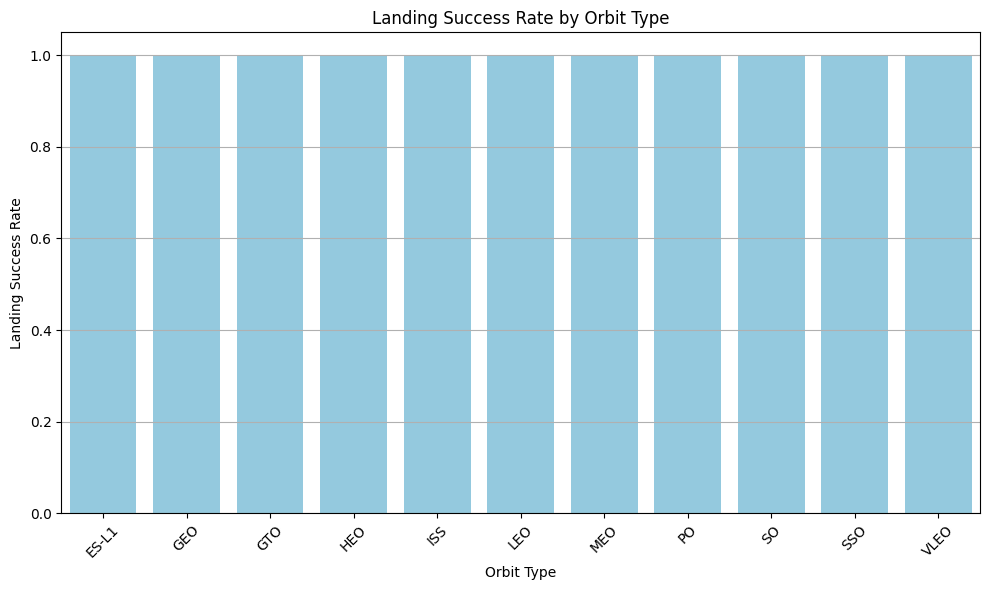

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate success rate for each orbit type
orbit_success_rate = df.groupby('Orbit')['landing_class'].mean().reset_index()

# Plot bar plot
plt.figure(figsize=(10, 6))
sns.barplot(data=orbit_success_rate, x='Orbit', y='landing_class', color='skyblue')

# Add title and labels
plt.title('Landing Success Rate by Orbit Type')
plt.xlabel('Orbit Type')
plt.ylabel('Landing Success Rate')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid for better readability
plt.grid(axis='y')

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()


In [119]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [120]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [121]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [122]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [123]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [124]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [125]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [126]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [127]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [128]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [129]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [130]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [131]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [132]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [133]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


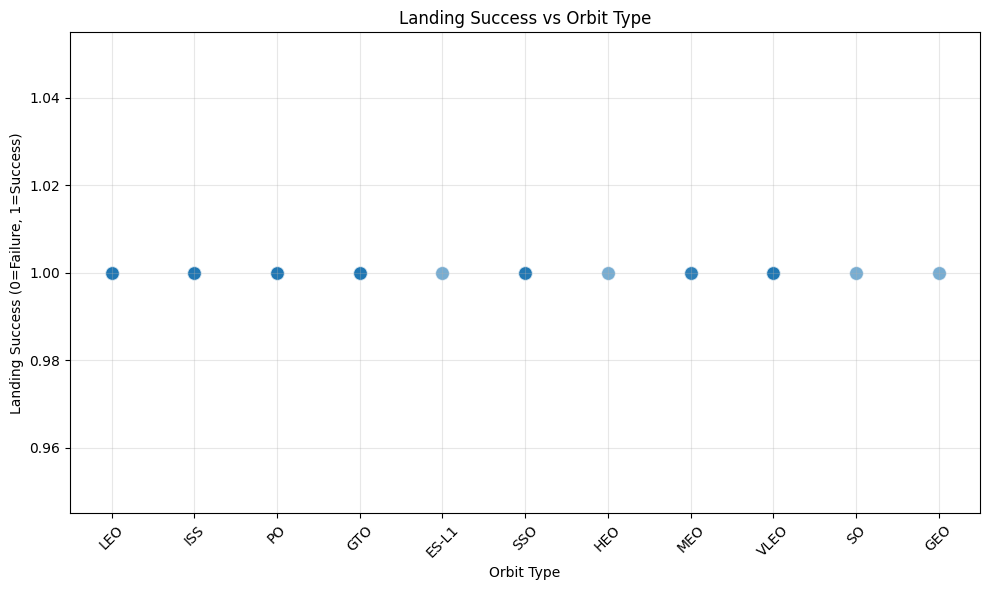

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Orbit', y='landing_class', alpha=0.6, s=100)

# Customize plot
plt.title('Landing Success vs Orbit Type')
plt.xlabel('Orbit Type')
plt.ylabel('Landing Success (0=Failure, 1=Success)')

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Add grid for better visibility
plt.grid(True, alpha=0.3)

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()



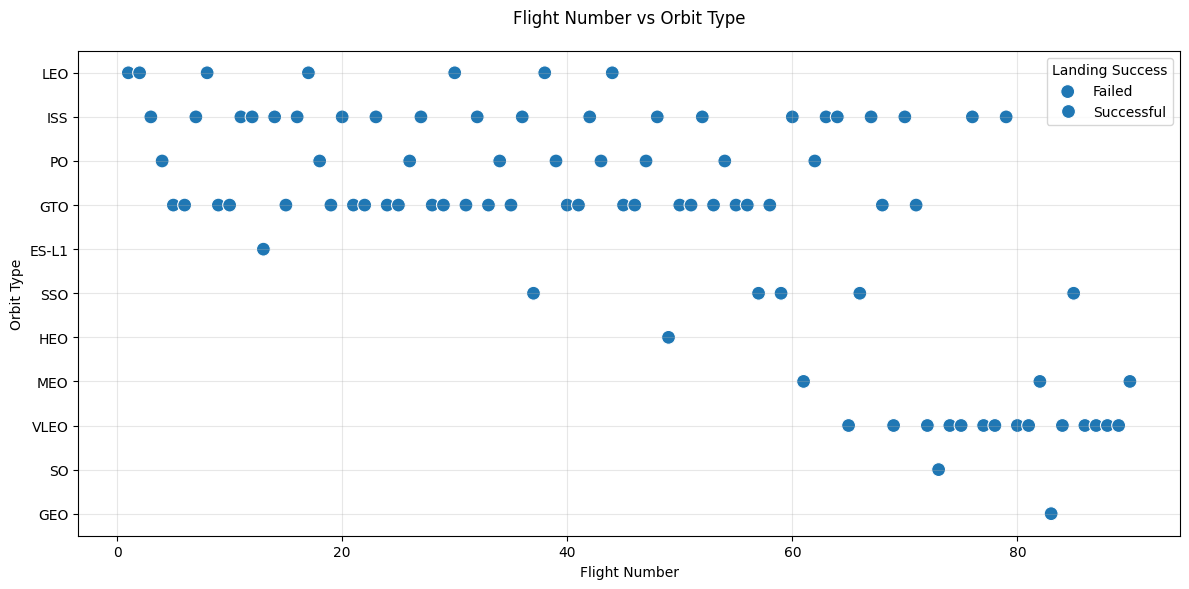

In [135]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create scatter plot
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='FlightNumber', y='Orbit', hue='landing_class', style='landing_class', s=100)

# Customize plot
plt.title('Flight Number vs Orbit Type', pad=20)
plt.xlabel('Flight Number')
plt.ylabel('Orbit Type')

# Add legend
plt.legend(title='Landing Success', labels=['Failed', 'Successful'])

# Add grid for better visibility
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

plt.show()


In [136]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [137]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


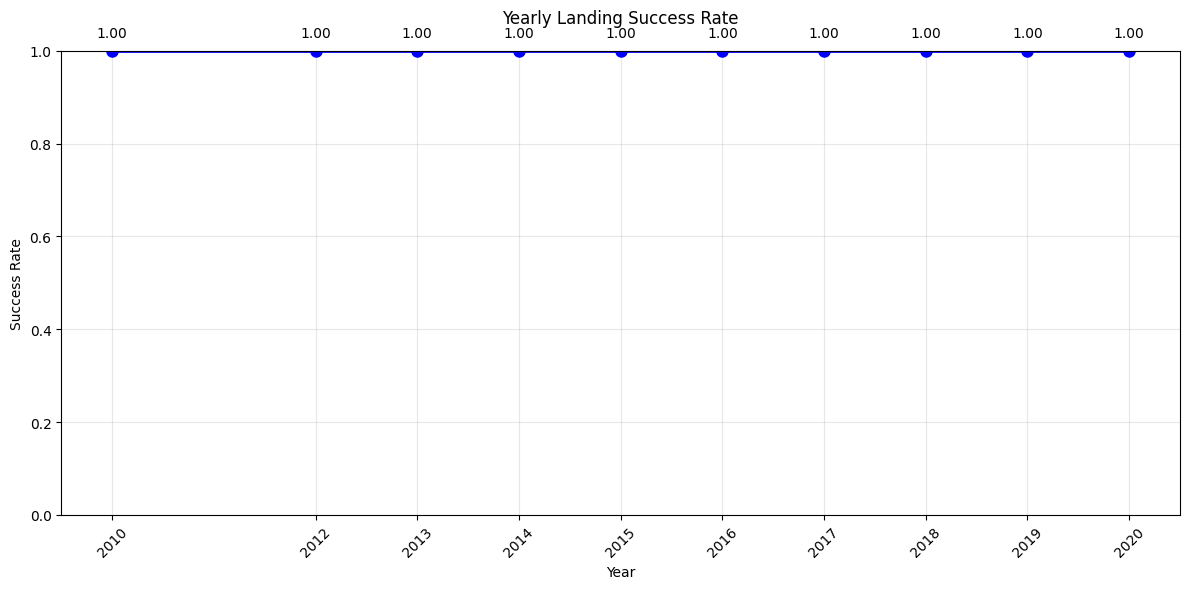

In [138]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract year from the Date column and calculate yearly success rate
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['landing_class'].mean().reset_index()

# Create line plot
plt.figure(figsize=(12, 6))

# Plot line with markers
plt.plot(yearly_success['Year'], yearly_success['landing_class'], 
         marker='o', linewidth=2, markersize=8, color='blue')

# Customize plot
plt.title('Yearly Landing Success Rate', pad=20)
plt.xlabel('Year')
plt.ylabel('Success Rate')

# Set y-axis limits from 0 to 1
plt.ylim(0, 1)

# Add grid
plt.grid(True, alpha=0.3)

# Add value labels on each point
for x, y in zip(yearly_success['Year'], yearly_success['landing_class']):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", 
                xytext=(0,10), ha='center')

# Rotate x-axis labels if needed
plt.xticks(yearly_success['Year'], rotation=45)

plt.tight_layout()
plt.show()


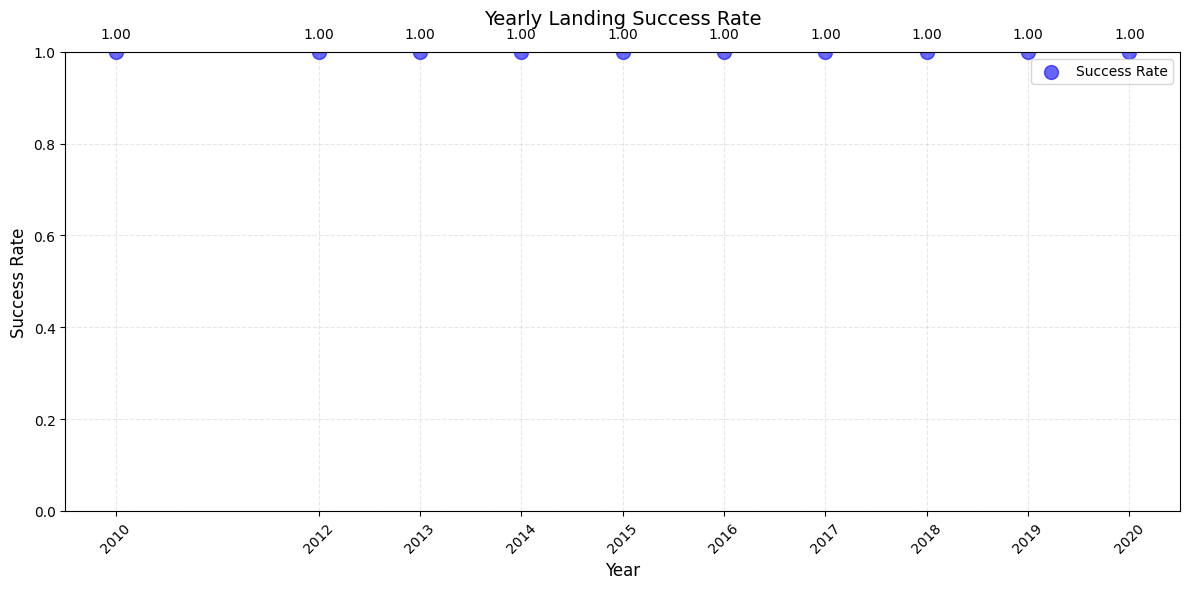

In [139]:
import pandas as pd
import matplotlib.pyplot as plt

# Extract year from the Date column and calculate yearly success rate
df['Year'] = pd.to_datetime(df['Date']).dt.year
yearly_success = df.groupby('Year')['landing_class'].mean().reset_index()

# Create scatter plot
plt.figure(figsize=(12, 6))

# Create scatter plot with larger points
plt.scatter(yearly_success['Year'], yearly_success['landing_class'], 
           s=100,  # Size of markers
           color='blue',
           alpha=0.6,  # Transparency
           label='Success Rate')

# Customize plot
plt.title('Yearly Landing Success Rate', pad=20, fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Success Rate', fontsize=12)

# Set y-axis limits from 0 to 1
plt.ylim(0, 1)

# Add grid
plt.grid(True, alpha=0.3, linestyle='--')

# Add value labels on each point
for x, y in zip(yearly_success['Year'], yearly_success['landing_class']):
    plt.annotate(f'{y:.2f}', 
                (x, y),
                textcoords="offset points", 
                xytext=(0, 10),  # 10 points vertical offset
                ha='center',     # Horizontal alignment
                fontsize=10)     # Font size of annotations

# Rotate x-axis labels if needed
plt.xticks(yearly_success['Year'], rotation=45)

# Add legend
plt.legend()

# Adjust layout to prevent label cutoff
plt.tight_layout()

plt.show()


In [140]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class', 'Year']


In [141]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class', 'Year']


In [142]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class', 'Year']


First Successful Landing Details:
Date: 2010-06-04
Launch Site: CCAFS SLC 40
Landing Outcome: None None
Payload: 6104.959411764706
Orbit: LEO


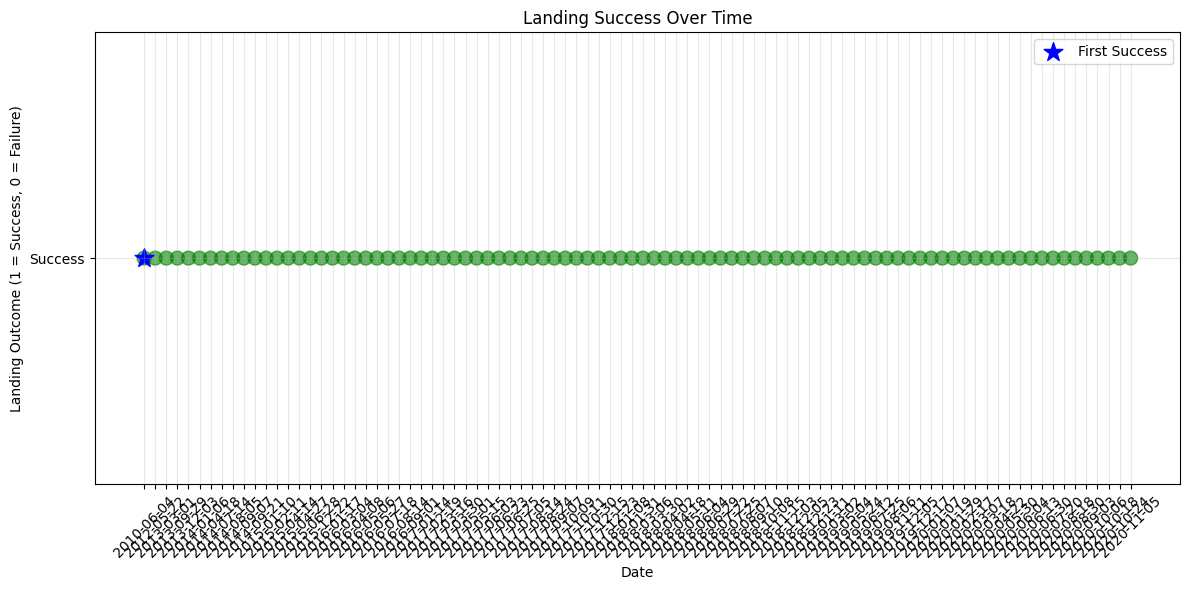


First few successful landings in chronological order:


KeyError: "['Landing Outcome', 'Booster Version', 'Launch Site'] not in index"

In [143]:
# Filter for successful landings (landing_class = 1)
successful_landings = df[df['landing_class'] == 1]

# Find the first successful landing date
first_success = successful_landings['Date'].min()

# Get complete information about the first successful landing
first_success_details = successful_landings[successful_landings['Date'] == first_success].iloc[0]

# Display the results
print("First Successful Landing Details:")
print(f"Date: {first_success_details['Date']}")
print(f"Launch Site: {first_success_details['LaunchSite']}")
print(f"Landing Outcome: {first_success_details['Outcome']}")
print(f"Payload: {first_success_details['PayloadMass']}")
print(f"Orbit: {first_success_details['Orbit']}")

# Create a visualization of landing outcomes over time
plt.figure(figsize=(12, 6))

# Create scatter plot
plt.scatter(df['Date'], 
           df['landing_class'],
           c=df['landing_class'].map({1: 'green', 0: 'red'}),
           alpha=0.6,
           s=100)

# Add title and labels
plt.title('Landing Success Over Time')
plt.xlabel('Date')
plt.ylabel('Landing Outcome (1 = Success, 0 = Failure)')

# Customize y-axis
plt.yticks([0, 1], ['Failure', 'Success'])

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True, alpha=0.3)

# Highlight first successful landing
plt.scatter(first_success, 1, 
           c='blue', 
           s=200, 
           marker='*', 
           label='First Success')

plt.legend()
plt.tight_layout()
plt.show()

# Display chronological list of first few successful landings
print("\nFirst few successful landings in chronological order:")
display(successful_landings.sort_values('Date')[['Date', 'Landing Outcome', 'Booster Version', 'Launch Site']].head())


In [49]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class', 'Year']


In [ ]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


In [36]:
df.head(5) #to show first 5 rows of the dataset


,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,landing_class,Year
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,1,2010
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,1,2012
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,1,2013
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,1,2013
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,1,2013


In [ ]:
# Print column names to verify
print("Available columns in dataframe:")
print(df.columns.tolist())


Available columns in dataframe:
['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'landing_class']


Boosters that landed on drone ship with payload mass between 4000-6000 kg:


,BoosterVersion,PayloadMass,Outcome,Date


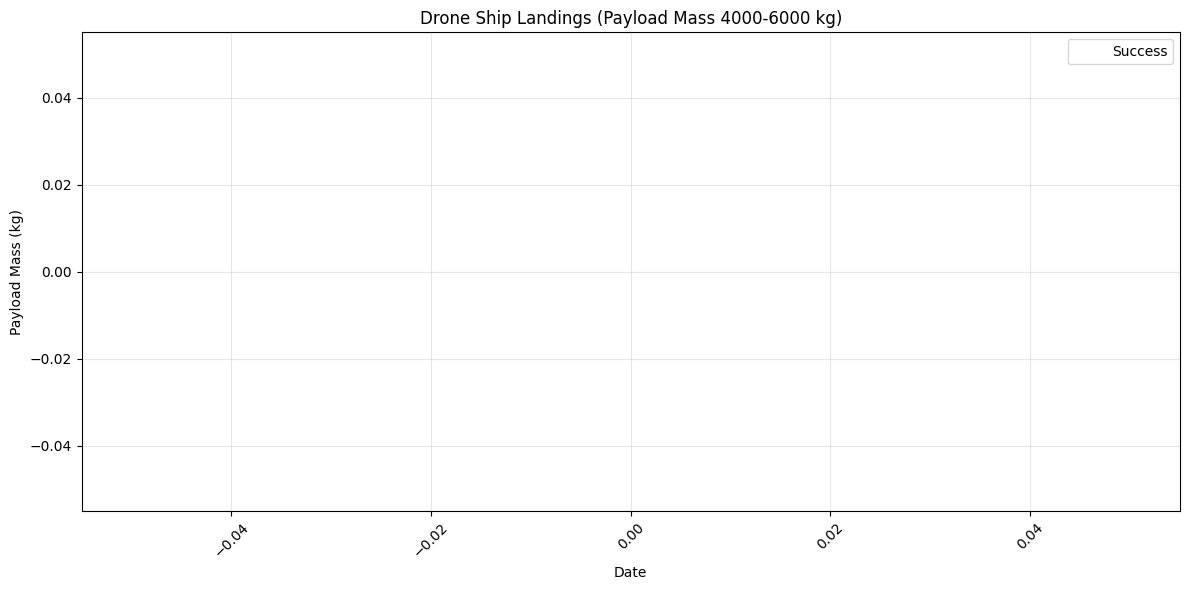


Summary Statistics:
Total number of matching launches: 0
Successful landings: 0
Failed landings: 0

Average Payload Mass: nan kg
Median Payload Mass: nan kg


In [87]:
# Filter the dataframe for drone ship landings and payload mass between 4000-6000
drone_ship_landings = df[
    (df['Outcome'].str.contains('drone ship', na=False)) & 
    (df['PayloadMass'].between(4000, 6000))
]

# Sort by PayloadMass for better readability
drone_ship_filtered = drone_ship_landings.sort_values('PayloadMass')

# Display relevant columns
print("Boosters that landed on drone ship with payload mass between 4000-6000 kg:")
display(drone_ship_filtered[['BoosterVersion', 'PayloadMass', 'Outcome', 'Date']])

# Create a visualization
plt.figure(figsize=(12, 6))

# Create scatter plot
plt.scatter(drone_ship_filtered['Date'], 
           drone_ship_filtered['PayloadMass'],
           c=drone_ship_filtered['landing_class'].map({1: 'green', 0: 'red'}),
           s=100)

# Customize plot
plt.title('Drone Ship Landings (Payload Mass 4000-6000 kg)')
plt.xlabel('Date')
plt.ylabel('Payload Mass (kg)')

# Rotate x-axis labels
plt.xticks(rotation=45)

# Add grid
plt.grid(True, alpha=0.3)

# Add legend
plt.legend(['Success', 'Failure'])

# Adjust layout
plt.tight_layout()

plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(f"Total number of matching launches: {len(drone_ship_filtered)}")
print(f"Successful landings: {sum(drone_ship_filtered['landing_class'] == 1)}")
print(f"Failed landings: {sum(drone_ship_filtered['landing_class'] == 0)}")
print(f"\nAverage Payload Mass: {drone_ship_filtered['PayloadMass'].mean():.2f} kg")
print(f"Median Payload Mass: {drone_ship_filtered['PayloadMass'].median():.2f} kg")


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  landing_class   90 no

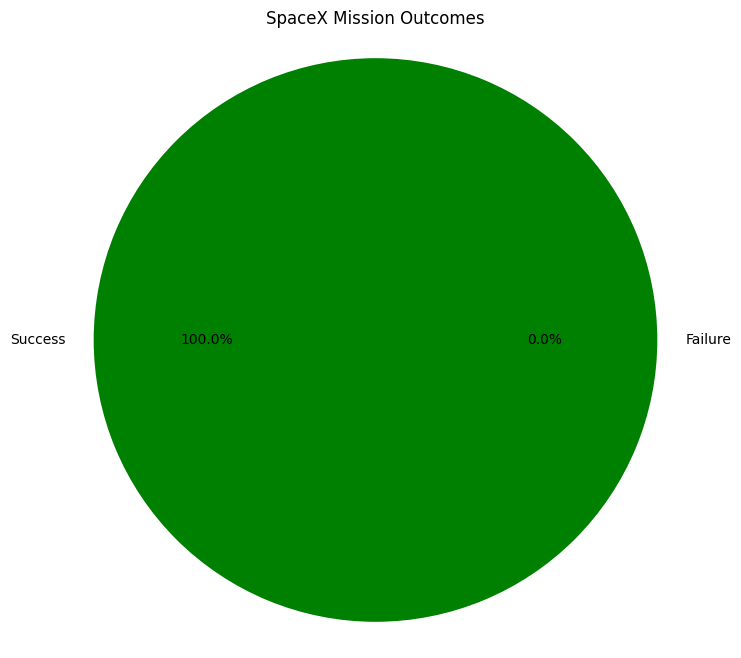

In [50]:
# First, let's verify the data and column names
print("DataFrame Info:")
print(df.info())

# Check if 'Class' column exists
print("\nColumns in the DataFrame:")
print(df.columns.tolist())

# Now calculate the outcomes
# If your column is named 'Class':
success_count = df[df['landing_class'] == 1].shape[0]
failure_count = df[df['landing_class'] == 0].shape[0]

# Print the results
print(f"\nTotal Successful Missions: {success_count}")
print(f"Total Failed Missions: {failure_count}")
print(f"Total Missions: {success_count + failure_count}")

# Calculate success rate
success_rate = (success_count / (success_count + failure_count)) * 100
print(f"\nSuccess Rate: {success_rate:.2f}%")

# Visualize with pie chart
import matplotlib.pyplot as plt

labels = ['Success', 'Failure']
sizes = [success_count, failure_count]
colors = ['green', 'red']

plt.figure(figsize=(8, 8))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')
plt.title('SpaceX Mission Outcomes')
plt.axis('equal')
plt.show()


In [49]:
# First, let's check if the DataFrame exists and its basic information
print("DataFrame Info:")
print(df.info())

# Check if 'PayloadMass' and 'BoosterVersion' columns exist
print("\nColumns in DataFrame:")
print(df.columns)

# Check the first few rows of relevant columns
print("\nFirst few rows of PayloadMass and BoosterVersion:")
print(df[['PayloadMass', 'BoosterVersion']].head())


DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   FlightNumber    90 non-null     int64  
 1   Date            90 non-null     object 
 2   BoosterVersion  90 non-null     object 
 3   PayloadMass     90 non-null     float64
 4   Orbit           90 non-null     object 
 5   LaunchSite      90 non-null     object 
 6   Outcome         90 non-null     object 
 7   Flights         90 non-null     int64  
 8   GridFins        90 non-null     bool   
 9   Reused          90 non-null     bool   
 10  Legs            90 non-null     bool   
 11  LandingPad      64 non-null     object 
 12  Block           90 non-null     float64
 13  ReusedCount     90 non-null     int64  
 14  Serial          90 non-null     object 
 15  Longitude       90 non-null     float64
 16  Latitude        90 non-null     float64
 17  landing_class   90 no

In [50]:
# Find the booster which has carried the maximum payload mass
max_payload_booster = df.loc[df['PayloadMass'].idxmax()]['BoosterVersion']
print(f"\nThe booster which has carried the maximum payload mass is: {max_payload_booster}")

# Additional analysis
max_payload = df['PayloadMass'].max()
print(f"Maximum payload mass: {max_payload} kg")

# Show full details of the launch with maximum payload
print("\nFull details of the launch with maximum payload:")
print(df.loc[df['PayloadMass'].idxmax()])



The booster which has carried the maximum payload mass is: Falcon 9
Maximum payload mass: 15600.0 kg

Full details of the launch with maximum payload:
FlightNumber                            69
Date                            2019-11-11
BoosterVersion                    Falcon 9
PayloadMass                        15600.0
Orbit                                 VLEO
LaunchSite                    CCAFS SLC 40
Outcome                          True ASDS
Flights                                  4
GridFins                              True
Reused                                True
Legs                                  True
LandingPad        5e9e3032383ecb6bb234e7ca
Block                                  5.0
ReusedCount                              4
Serial                               B1048
Longitude                       -80.577366
Latitude                         28.561857
landing_class                            1
Year                                  2019
Name: 68, dtype: object


In [49]:
# Filter for year 2015 and failed drone ship landings
failed_landings_2015 = df[(df['Date'] == '2015') & 
                         (df['Outcome'].str.contains('False', na=False)) &
                         (df['Outcome'].str.contains('drone', na=False, case=False))]

# Select relevant columns
result = failed_landings_2015[['Date', 'BoosterVersion', 'LaunchSite', 'Outcome']]

print("Failed Drone Ship Landings in 2015:")
print(result)
# First, let's check the format of dates in your DataFrame
print("Sample of dates in the DataFrame:")
print(df['Date'].head())

# Modified code to handle date filtering
# Convert Date column to datetime if it's not already
df['Date'] = pd.to_datetime(df['Date'])

# Filter for year 2015 and failed drone ship landings
failed_landings_2015 = df[(df['Date'].dt.year == 2015) & 
                         (df['Outcome'].str.contains('False', na=False)) &
                         (df['Outcome'].str.contains('drone', na=False, case=False))]

# Select relevant columns
result = failed_landings_2015[['Date', 'BoosterVersion', 'LaunchSite', 'Outcome']]

print("\nFailed Drone Ship Landings in 2015:")
print(result)


Failed Drone Ship Landings in 2015:
Empty DataFrame
Columns: [Date, BoosterVersion, LaunchSite, Outcome]
Index: []
Sample of dates in the DataFrame:
0   2010-06-04
1   2012-05-22
2   2013-03-01
3   2013-09-29
4   2013-12-03
Name: Date, dtype: datetime64[ns]

Failed Drone Ship Landings in 2015:
Empty DataFrame
Columns: [Date, BoosterVersion, LaunchSite, Outcome]
Index: []


In [51]:
import folium

# Create a base map centered at a middle point
site_map = folium.Map(location=[30.0, -90.0], zoom_start=4)

# For each launch site in your dataset, add a marker
# First get unique launch sites with their coordinates
launch_sites = df[['LaunchSite', 'Lat', 'Long']].drop_duplicates()

# Add markers for each launch site
for idx, site in launch_sites.iterrows():
    folium.Marker(
        location=[site['Lat'], site['Long']],
        popup=site['LaunchSite'],
        icon=folium.Icon(color='red', icon='info-sign')
    ).add_to(site_map)

# Display the map
site_map

# To save the map
site_map.save('spacex_launch_sites.html')


ModuleNotFoundError: No module named 'folium'

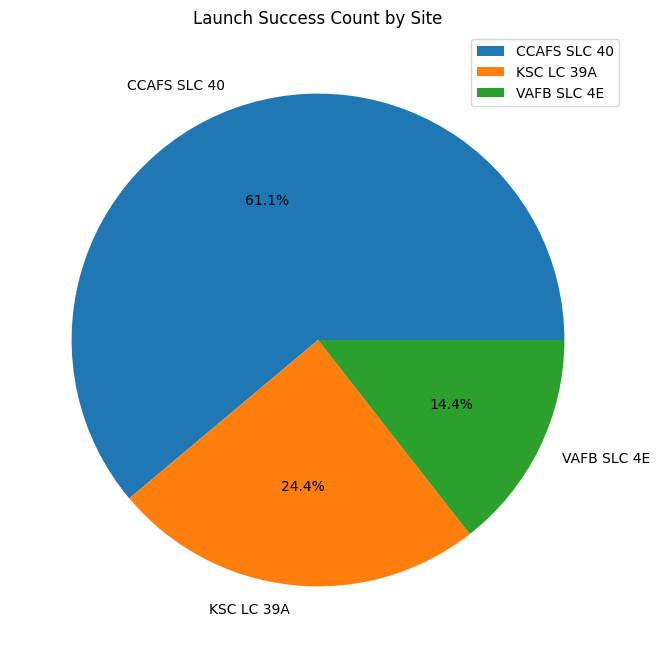

In [52]:
import matplotlib.pyplot as plt

# Count successful launches by site
success_by_site = df[df['landing_class'] == 1].groupby('LaunchSite').size()

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie(success_by_site.values, labels=success_by_site.index, autopct='%1.1f%%')
plt.title('Launch Success Count by Site')

# Add legend
plt.legend(loc='best')

# Show the plot
plt.show()


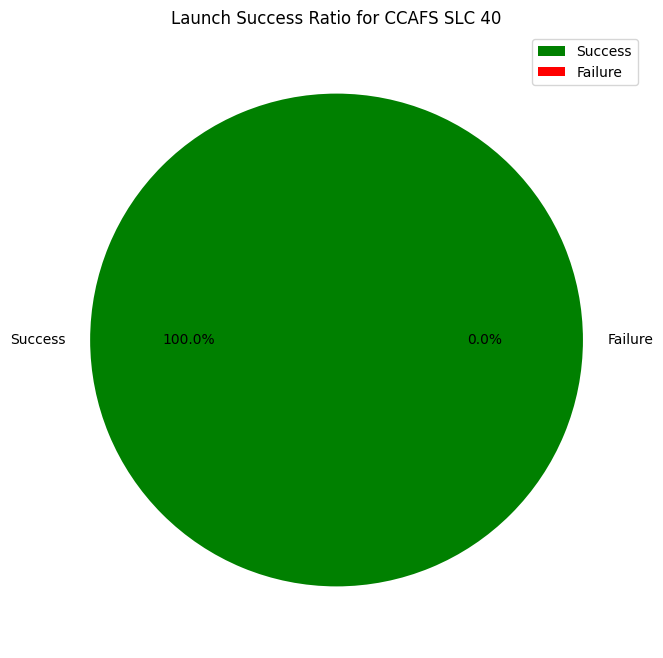

In [57]:
import matplotlib.pyplot as plt

# Calculate success ratio for each site
site_counts = df.groupby('LaunchSite')['landing_class'].agg(['sum', 'count'])
site_counts['success_ratio'] = site_counts['sum'] / site_counts['count']

# Find the site with highest success ratio
best_site = site_counts['success_ratio'].idxmax()

# Filter data for the best site
best_site_data = df[df['LaunchSite'] == best_site]
success_counts = best_site_data['landing_class'].value_counts()

# Create the values for the pie chart
successes = success_counts.get(1, 0)  # Get count of 1s (successes)
failures = success_counts.get(0, 0)   # Get count of 0s (failures)

# Create pie chart
plt.figure(figsize=(10, 8))
plt.pie([successes, failures], 
        labels=['Success', 'Failure'], 
        autopct='%1.1f%%',
        colors=['green', 'red'])
plt.title(f'Launch Success Ratio for {best_site}')

# Add legend
plt.legend()

# Show the plot
plt.show()


In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatRangeSlider
import ipywidgets as widgets

def plot_payload_vs_outcome(payload_range):
    # Filter data based on payload range
    mask = (df['PayloadMass'] >= payload_range[0]) & (df['PayloadMass'] <= payload_range[1])
    filtered_df = df[mask]
    
    # Create scatter plot
    plt.figure(figsize=(12, 8))
    
    # Plot for each launch site
    for site in filtered_df['LaunchSite'].unique():
        site_data = filtered_df[filtered_df['LaunchSite'] == site]
        plt.scatter(site_data['PayloadMass'], 
                   site_data['landing_class'],
                   label=site,
                   alpha=0.6)
    
    plt.xlabel('Payload Mass (kg)')
    plt.ylabel('Launch Outcome (0=Failure, 1=Success)')
    plt.title('Payload vs. Launch Outcome by Site')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

# Create the range slider
payload_range = FloatRangeSlider(
    value=[df['PayloadMass'].min(), df['PayloadMass'].max()],
    min=df['PayloadMass'].min(),
    max=df['PayloadMass'].max(),
    step=100,
    description='Payload Range (kg):',
    continuous_update=False,
    layout={'width': '500px'}
)

# Display interactive plot
interact(plot_payload_vs_outcome, payload_range=payload_range)


interactive(children=(FloatRangeSlider(value=(350.0, 15600.0), continuous_update=False, description='Payload R…

<function __main__.plot_payload_vs_outcome(payload_range)>

Column names in the dataframe:
Index(['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit',
       'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs',
       'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude',
       'landing_class', 'Year'],
      dtype='object')

First few rows of the relevant columns:
   PayloadMass    LaunchSite  landing_class
0  6104.959412  CCAFS SLC 40              1
1   525.000000  CCAFS SLC 40              1
2   677.000000  CCAFS SLC 40              1
3   500.000000   VAFB SLC 4E              1
4  3170.000000  CCAFS SLC 40              1


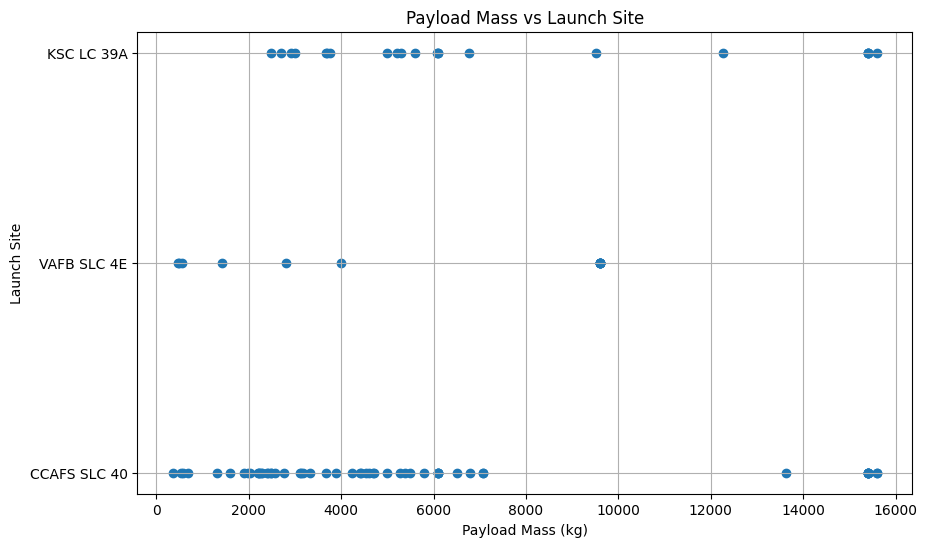

In [144]:
# First, let's check our data
print("Column names in the dataframe:")
print(df.columns)

print("\nFirst few rows of the relevant columns:")
print(df[['PayloadMass', 'LaunchSite', 'landing_class']].head())

# Now let's create a basic scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(df['PayloadMass'], df['LaunchSite'])
plt.xlabel('Payload Mass (kg)')
plt.ylabel('Launch Site')
plt.title('Payload Mass vs Launch Site')
plt.grid(True)
plt.show()


<a href="https://www.linkedin.com/in/joseph-s-50398b136/">Joseph Santarcangelo</a> has a PhD in Electrical Engineering, his research focused on using machine learning, signal processing, and computer vision to determine how videos impact human cognition. Joseph has been working for IBM since he completed his PhD.


<a href="https://www.linkedin.com/in/nayefaboutayoun/">Nayef Abou Tayoun</a> is a Data Scientist at IBM and pursuing a Master of Management in Artificial intelligence degree at Queen's University.


## Change Log


| Date (YYYY-MM-DD) | Version | Changed By | Change Description      |
| ----------------- | ------- | ---------- | ----------------------- |
| 2021-08-31        | 1.1     | Lakshmi Holla    | Changed Markdown |
| 2020-09-20        | 1.0     | Joseph     | Modified Multiple Areas |
| 2020-11-04        | 1.1.    | Nayef      | updating the input data |
| 2021-05-026       | 1.1.    | Joseph      | updating the input data |


Copyright © 2021 IBM Corporation. All rights reserved.
